In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn.metrics as sk_metrics
import tempfile
matplotlib.rcParams["figure.figsize"] = (9, 6)
tf.random.set_seed(22)

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'
features = ["radius", "texture", "perimeter", "area", "smoothness", "compactness", "concavity", "concave points", "symmetry", "fractal dimension"]
column_names = ["id", "diagnosis"]
for attr in ["mean", "ste", "largest"]:
    for feature in features:
        column_names.append(feature + "_" + attr)

In [3]:
dataset = pd.read_csv(url, names=column_names)

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         569 non-null    int64  
 1   diagnosis                  569 non-null    str    
 2   radius_mean                569 non-null    float64
 3   texture_mean               569 non-null    float64
 4   perimeter_mean             569 non-null    float64
 5   area_mean                  569 non-null    float64
 6   smoothness_mean            569 non-null    float64
 7   compactness_mean           569 non-null    float64
 8   concavity_mean             569 non-null    float64
 9   concave points_mean        569 non-null    float64
 10  symmetry_mean              569 non-null    float64
 11  fractal dimension_mean     569 non-null    float64
 12  radius_ste                 569 non-null    float64
 13  texture_ste                569 non-null    float64
 14  perim

In [5]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave points_largest,symmetry_largest,fractal dimension_largest
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
train_dataset = dataset.sample(frac=0.75, random_state=1)

In [7]:
len(train_dataset)

427

In [8]:
test_dataset = dataset.drop(train_dataset.index)

In [9]:
len(test_dataset)

142

In [10]:
x_train, y_train = train_dataset.iloc[:, 2:], train_dataset.iloc[:, 1]
x_test, y_test = test_dataset.iloc[:, 2:], test_dataset.iloc[:, 1]

In [11]:
y_train = y_train.map({"M": 1, "B": 0})
y_test = y_test.map({"M": 1, "B": 0})
x_train, y_train = tf.convert_to_tensor(x_train, dtype=tf.float32), tf.convert_to_tensor(y_train, dtype=tf.float32)
x_test, y_test = tf.convert_to_tensor(x_test, dtype=tf.float32), tf.convert_to_tensor(y_test, dtype=tf.float32)

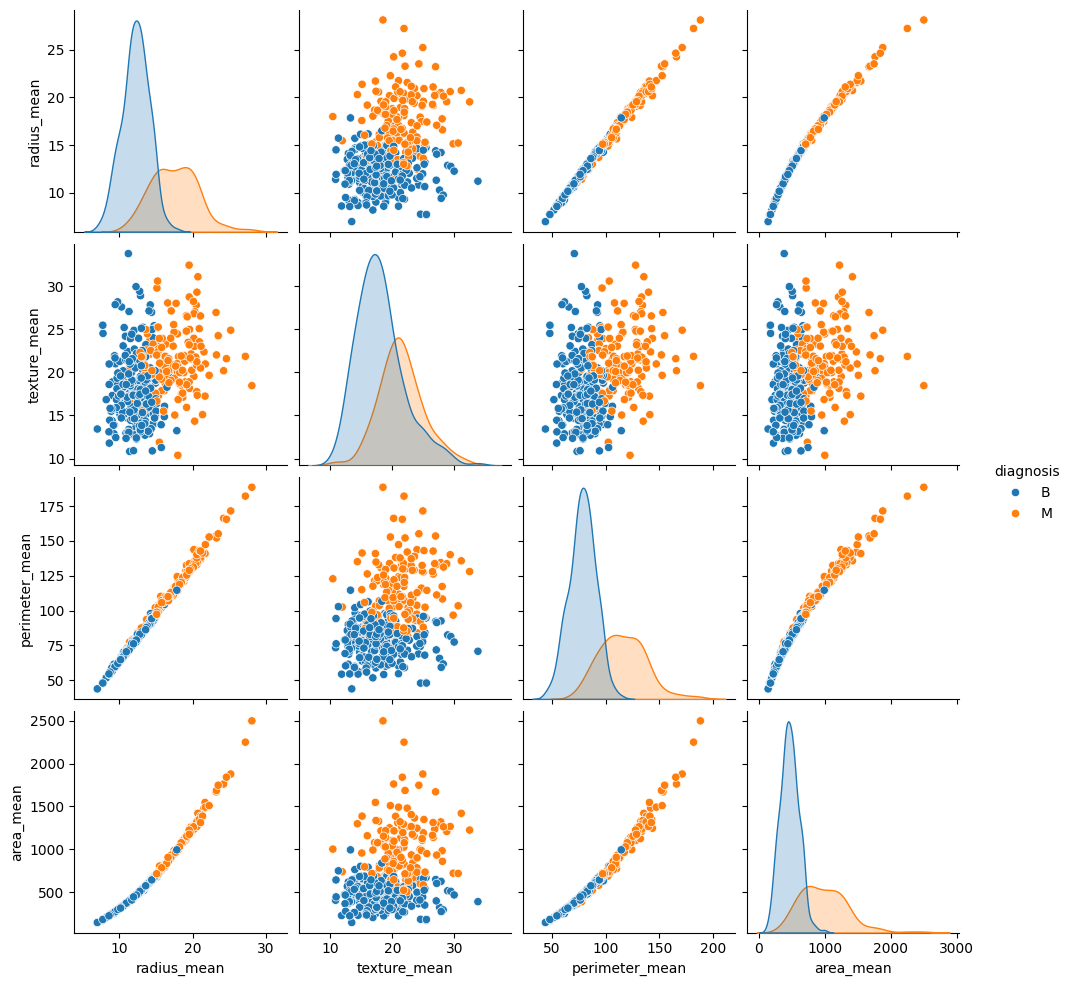

In [12]:
sns.pairplot(train_dataset.iloc[:, 1:6], hue="diagnosis", diag_kind="kde")

In [13]:
train_dataset.describe().transpose()[:10]

,count,mean,std,min,25%,50%,75%,max
id,427.0,2.756014e+07,1.162735e+08,8670.00000,865427.500000,905539.00000,8.810829e+06,9.113205e+08
radius_mean,427.0,1.414331e+01,3.528717e+00,6.98100,11.695000,13.43000,1.594000e+01,2.811000e+01
texture_mean,427.0,1.924468e+01,4.113131e+00,10.38000,16.330000,18.84000,2.168000e+01,3.381000e+01
perimeter_mean,427.0,9.206759e+01,2.431431e+01,43.79000,75.235000,86.87000,1.060000e+02,1.885000e+02
area_mean,427.0,6.563190e+02,3.489106e+02,143.50000,420.050000,553.50000,7.908500e+02,2.499000e+03
smoothness_mean,427.0,9.633618e-02,1.436820e-02,0.05263,0.085850,0.09566,1.050000e-01,1.634000e-01
compactness_mean,427.0,1.036597e-01,5.351893e-02,0.02344,0.063515,0.09182,1.296500e-01,3.454000e-01
concavity_mean,427.0,8.833008e-02,7.965884e-02,0.00000,0.029570,0.05999,1.297500e-01,4.268000e-01
concave points_mean,427.0,4.872688e-02,3.853594e-02,0.00000,0.019650,0.03390,7.409500e-02,2.012000e-01
symmetry_mean,427.0,1.804597e-01,2.637837e-02,0.12030,0.161700,0.17840,1.947000e-01,2.906000e-01


In [14]:
class Normalize(tf.Module):
    def __init__(self, x):
        super().__init__()
        self.mean = tf.Variable(tf.math.reduce_mean(x, axis=0))
        self.std = tf.Variable(tf.math.reduce_std(x, axis=0))

    def norm(self, x):
        return (x - self.mean) / self.std

    def unnorm(self, x):
        return x * self.std + self.mean

norm_x = Normalize(x_train)
x_train_norm, x_test_norm = norm_x.norm(x_train), norm_x.norm(x_test)

Text(0.5, 1.0, 'Sigmoid Function')

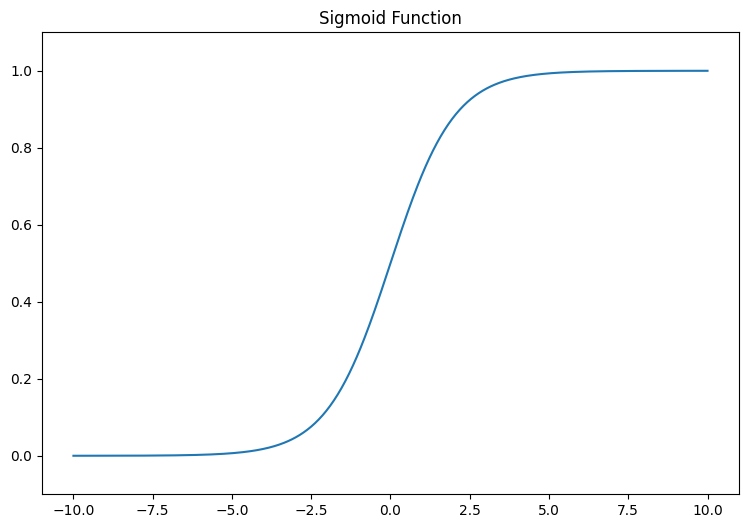

In [15]:
x = tf.linspace(-10, 10, 500)
x = tf.cast(x, tf.float32)
f = lambda x: (1 / 20) * x + 0.6
plt.plot(x, tf.math.sigmoid(x))
plt.ylim(-0.1, 1.1)
plt.title("Sigmoid Function")

In [16]:
def log_loss(y_pred, y):
    ce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=y_pred)
    return tf.reduce_mean(ce)

In [17]:
class LogisticRegression(tf.Module):
    def __init__(self):
        super().__init__()
        self.built = False

    def __call__(self, x, train=True):
        if not self.built:
            rand_w =  tf.random.uniform(shape=[x.shape[-1], 1], seed=22)
            rand_b = tf.random.uniform(shape=[], seed=22)
            self.w = tf.Variable(rand_w)
            self.b = tf.Variable(rand_b)
            self.built = True
        z = tf.add(tf.matmul(x, self.w), self.b)
        z = tf.squeeze(z, axis=1)
        if train:
            return z
        return tf.sigmoid(z)

In [18]:
log_reg = LogisticRegression()

In [19]:
y_pred = log_reg(x_train_norm[:5], train=False)
y_pred.numpy()

array([0.9994984 , 0.9978607 , 0.2962006 , 0.01979047, 0.33149227],
      dtype=float32)

In [20]:
def predict_class(y_pred, tresh=0.5):
    return tf.cast(y_pred > tresh, tf.float32)

def accuracy(y_pred, y):
    y_pred = tf.math.sigmoid(y_pred)
    y_pred_class = predict_class(y_pred)
    check_equal = tf.cast(y_pred_class == y, tf.float32)
    acc_val = tf.reduce_mean(check_equal)
    return acc_val

In [21]:
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train))
train_dataset = train_dataset.shuffle(buffer_size=x_train.shape[0]).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test))
test_dataset = test_dataset.shuffle(buffer_size=x_test.shape[0]).batch(batch_size)

In [22]:
epochs = 200
learning_rate = 0.01
train_losses, test_losses = [], []
train_accs, test_accs = [], []
for epoch in range(epochs):
    batch_losses_train, batch_accs_train = [], []
    batch_losses_test, batch_accs_test = [], []
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            y_pred_batch = log_reg(x_batch)
            batch_loss = log_loss(y_pred_batch, y_batch)
        batch_acc = accuracy(y_pred_batch, y_batch)
        grads = tape.gradient(batch_loss, log_reg.variables)
        for g, v in zip(grads, log_reg.variables):
            v.assign_sub(learning_rate * g)
        batch_losses_train.append(batch_loss)
        batch_accs_train.append(batch_acc)
    for x_batch, y_batch in test_dataset:
        y_pred_batch = log_reg(x_batch)
        batch_loss = log_loss(y_pred_batch, y_batch)
        batch_acc = accuracy(y_pred_batch, y_batch)
        batch_losses_test.append(batch_loss)
        batch_accs_test.append(batch_acc)
    train_loss, train_acc = tf.reduce_mean(batch_losses_train), tf.reduce_mean(batch_accs_train)
    test_loss, test_acc = tf.reduce_mean(batch_losses_test), tf.reduce_mean(batch_accs_test)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_loss}, Train Acc: {train_acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

Epoch 0, Train Loss: 0.6605852246284485, Train Acc: 0.8371573686599731, Test Loss: 0.7437658905982971, Test Acc: 0.8824405074119568
Epoch 20, Train Loss: 0.4180915653705597, Train Acc: 0.8796200156211853, Test Loss: 0.4406774342060089, Test Acc: 0.9114583134651184
Epoch 40, Train Loss: 0.26913949847221375, Train Acc: 0.9119601249694824, Test Loss: 0.2745119035243988, Test Acc: 0.9375
Epoch 60, Train Loss: 0.17838916182518005, Train Acc: 0.9274812936782837, Test Loss: 0.21087533235549927, Test Acc: 0.9055059552192688
Epoch 80, Train Loss: 0.1370542049407959, Train Acc: 0.9464804530143738, Test Loss: 0.2793482840061188, Test Acc: 0.926339328289032
Epoch 100, Train Loss: 0.11648933589458466, Train Acc: 0.9576411843299866, Test Loss: 0.19311654567718506, Test Acc: 0.9553571343421936
Epoch 120, Train Loss: 0.10575682669878006, Train Acc: 0.9621054530143738, Test Loss: 0.08150075376033783, Test Acc: 0.9791666865348816
Epoch 140, Train Loss: 0.09608912467956543, Train Acc: 0.9676598906517029,

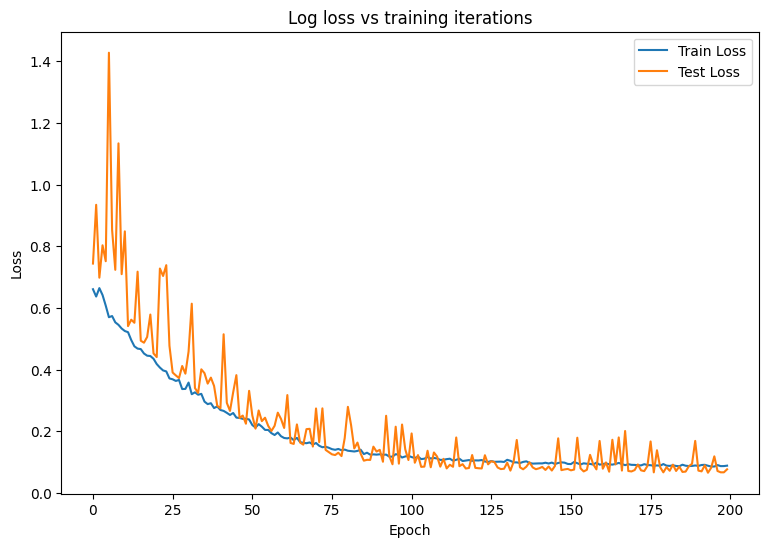

In [23]:
plt.plot(range(epochs), train_losses, label="Train Loss")
plt.plot(range(epochs), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Log loss vs training iterations")
plt.show()

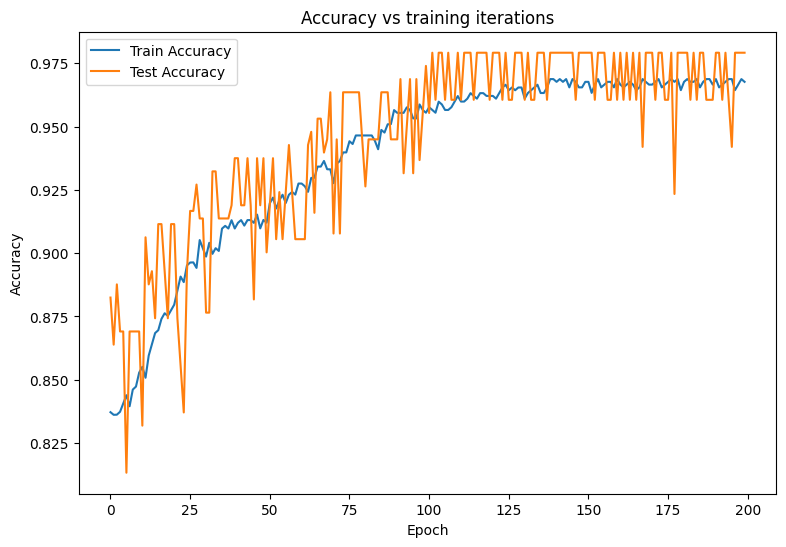

In [24]:
plt.plot(range(epochs), train_accs, label="Train Accuracy")
plt.plot(range(epochs), test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs training iterations")
plt.show()

In [25]:
print(f"Final training log loss: {train_losses[-1]:.3f}")
print(f"Final testing log Loss: {test_losses[-1]:.3f}")

Final training log loss: 0.089
Final testing log Loss: 0.077


In [26]:
print(f"Final training accuracy: {train_accs[-1]:.3f}")
print(f"Final testing accuracy: {test_accs[-1]:.3f}")

Final training accuracy: 0.968
Final testing accuracy: 0.979


In [27]:
def show_confusion_matrix(y, y_classes, typ):
    plt.figure(figsize=(10, 10))
    confusion = sk_metrics.confusion_matrix(y.numpy(), y_classes.numpy())
    confusion_normalized = confusion / confusion.sum(axis=1, keepdims=True)
    axis_labels = range(2)
    ax = sns.heatmap(confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels, cmap="Blues", annot=True, fmt="0.4f", square=True)
    plt.title(f"{typ} Confusion Matrix")
    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")


y_pred_train, y_pred_test = log_reg(x_train_norm, train=False), log_reg(x_test_norm, train=False)
train_classes, test_classes = predict_class(y_pred_train), predict_class(y_pred_test)

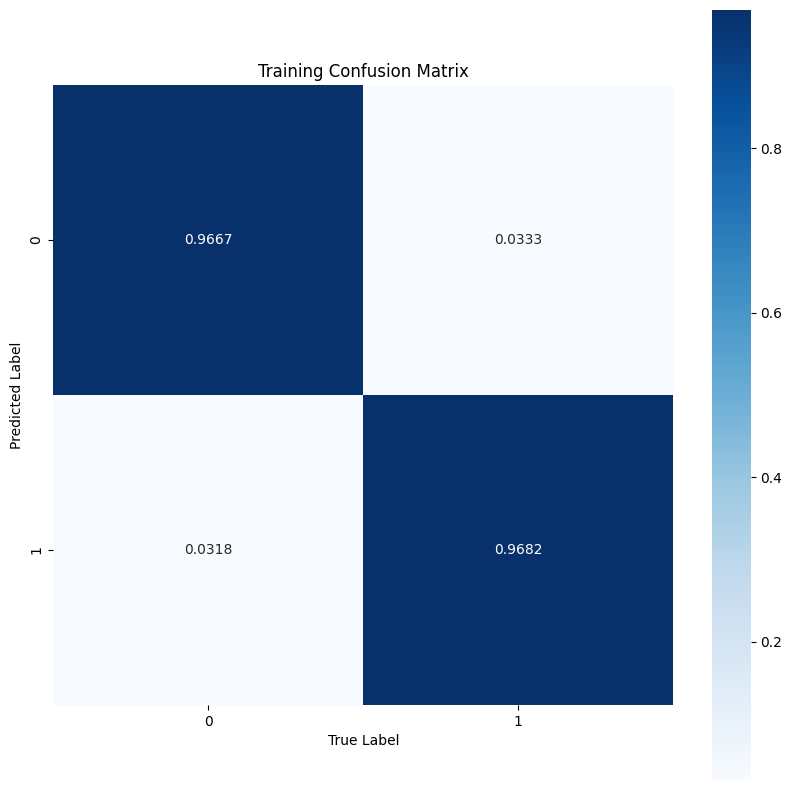

In [29]:
show_confusion_matrix(y_train, train_classes, "Training")

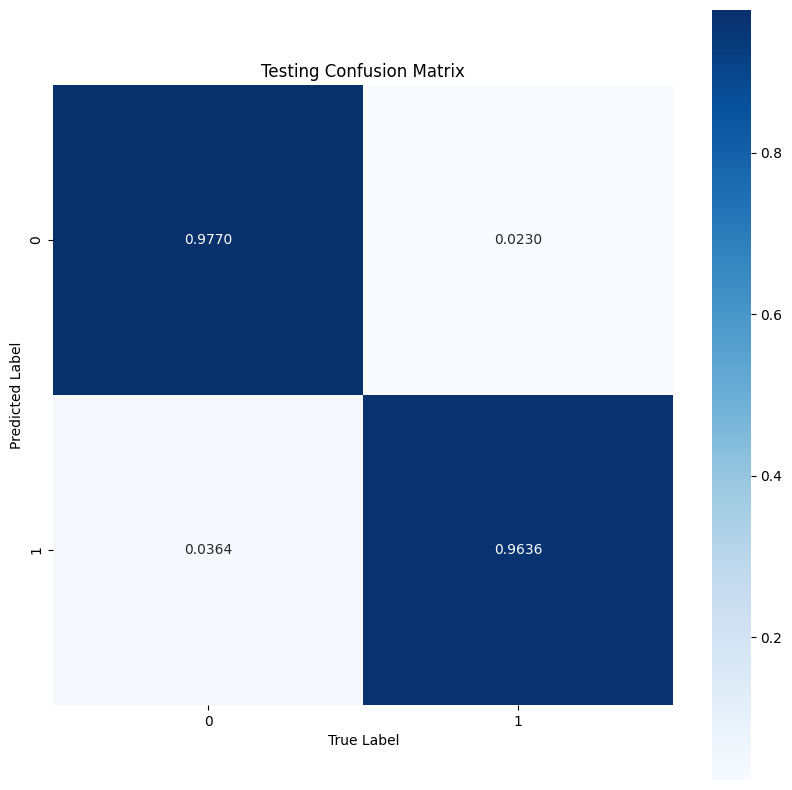

In [30]:
show_confusion_matrix(y_test, test_classes, "Testing")

In [31]:
class ExportModule(tf.Module):
    def __init__(self, model, norm_x, class_pred):
        super().__init__()
        self.model = model
        self.norm_x = norm_x
        self.class_pred = class_pred

    @tf.function(input_signature=[tf.TensorSpec(shape=[None, None], dtype=tf.float32)])
    def __call__(self, x, train=False):
        x = self.norm_x.norm(x)
        y = self.model(x, train=False)
        return self.class_pred(y)

In [32]:
log_reg_export = ExportModule(model=log_reg,
                              norm_x=norm_x,
                              class_pred=predict_class)

In [33]:
models = tempfile.mkdtemp()
save_path = os.path.join(models, 'log_reg_export')
tf.saved_model.save(log_reg_export, save_path)

INFO:tensorflow:Assets written to: /tmp/tmpxw9nr5r0/log_reg_export/assets


INFO:tensorflow:Assets written to: /tmp/tmpxw9nr5r0/log_reg_export/assets


In [34]:
log_reg_loaded = tf.saved_model.load(save_path)
test_preds = log_reg_loaded(x_test)
test_preds[:10].numpy()

array([1., 1., 1., 1., 0., 1., 1., 1., 1., 1.], dtype=float32)